## Dataset: PathMNIST

[PathMNIST](https://medmnist.com/) is part of the MedMNIST v2 collection: a 9-class colon pathology tissue classification dataset derived from NCT-CRC-HE-100K. Unlike CAMELYON17, it has no multi-center/domain-shift structure — it's a clean, patch-sized benchmark meant for fast iteration.

- **`pathmnist_224.npz`** — a single archive holding `train_images`/`train_labels`, `val_images`/`val_labels`, and `test_images`/`test_labels` arrays (224×224 RGB patches with integer class labels 0-8).
- **label semantics** — each integer label maps to a tissue type (e.g. tumor epithelium, stroma, lymphocytes, adipose, ...); see the `LABEL_NAMES` mapping below.

You can load the `.npz` directly to get an overview of class balance and split sizes, then sample a few images from each class to visualize.

In [1]:
import sys
sys.path.append("/home/shared/helper/")
from nbhelper import (
    pd
)

from nbhelper import (
    plt,
    np,
    pd,
    sns,
)

In [2]:
pathmnist_base_dir = "/home/shared/data/pathmnist/"
pathmnist_path = pathmnist_base_dir + "pathmnist_224_subset1000.npz"

LABEL_NAMES = {
    0: "adipose",
    1: "background",
    2: "debris",
    3: "lymphocytes",
    4: "mucus",
    5: "smooth muscle",
    6: "normal colon mucosa",
    7: "cancer-associated stroma",
    8: "colorectal adenocarcinoma epithelium",
}

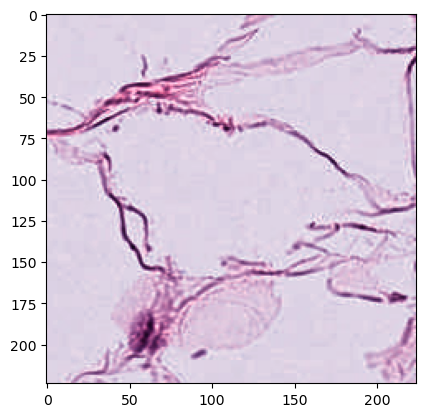

In [3]:
data = np.load(pathmnist_path)
plt.imshow(data["train_images"][0])

In [4]:
metadata_df = pd.concat(
    [
        pd.DataFrame(
            {
                "idx": np.arange(len(data[f"{split}_labels"])),
                "split": split,
                "label": data[f"{split}_labels"].reshape(-1),
            }
        )
        for split in ["train", "val", "test"]
    ],
    ignore_index=True,
).assign(label_name=lambda df_: df_["label"].map(LABEL_NAMES))
metadata_df

,idx,split,label,label_name
0,0,train,0,adipose
1,1,train,1,background
2,2,train,4,mucus
3,3,train,0,adipose
4,4,train,6,normal colon mucosa
...,...,...,...,...
995,62,test,5,smooth muscle
996,63,test,1,background
997,64,test,4,mucus
998,65,test,2,debris


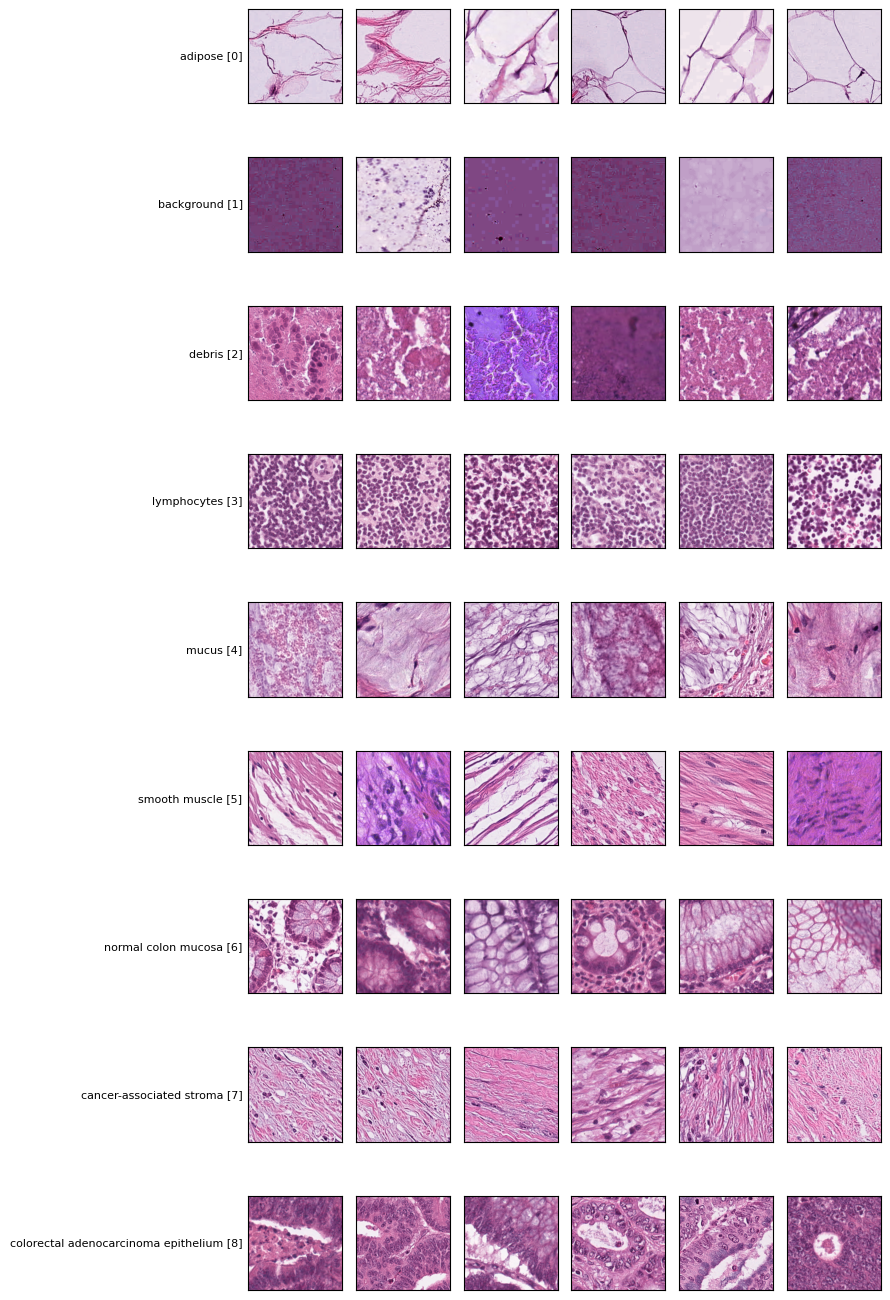

In [5]:
# plot a grid with one row per tissue class and k example patches per row

k = 6
train_images = data["train_images"]
train_labels = data["train_labels"].reshape(-1)

fig, axs = plt.subplots(len(LABEL_NAMES), k, figsize=(k * 1.5, len(LABEL_NAMES) * 1.5))

for row, label in enumerate(sorted(LABEL_NAMES)):
    idxs = np.where(train_labels == label)[0][:k]
    for col in range(k):
        ax = axs[row, col]
        if col < len(idxs):
            ax.imshow(train_images[idxs[col]])
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(f"{LABEL_NAMES[label]} [{label}]", rotation=0, ha="right", va="center", fontsize=8)

plt.tight_layout()

### Class balance

Are all 9 tissue types equally represented, or are some classes much rarer than others?

### Split distribution

Are classes distributed evenly across train/val/test, or does the split shift the balance for some tissue types?

### Per-class visual variability

Sample many images from a single class — how much intra-class variation is there in texture, color, and structure?

### Most visually similar classes

Some tissue types look alike (e.g. cancer-associated stroma vs. smooth muscle) — pick a couple of classes and compare grids of examples side by side.

### Color/intensity stats per class

Compute mean RGB per class — H&E staining intensity and hue can differ noticeably between tissue types.

### Effect of resolution

MedMNIST also ships PathMNIST at 28/64/128px. Downsample a 224px example to see how much structure survives at the smaller sizes.

### The background class

Label 1 ("background") isn't biological tissue like the other 8 classes — see how it stands out visually from the rest.

### Library to access PathMNIST data
There is also a library to make data handling easier. If you want you can explore it more:

In [6]:
from medmnist import PathMNIST, INFO

dataset = PathMNIST(split="train", download=True, root=pathmnist_base_dir, size=224)

print("Dataset:", dataset)
print("Num examples:", len(dataset))
print("Classes:", INFO["pathmnist"]["label"])
print("\nSaved to:", pathmnist_base_dir)

Dataset: Dataset PathMNIST of size 224 (pathmnist_224)
    Number of datapoints: 89996
    Root location: /home/shared/data/pathmnist/
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
    Number of samples: {'train': 89996, 'val': 10004, 'test': 7180}
    Description: The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28